In [1]:
import sys
sys.path.append('../')

import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as m_colors
from matplotlib.patches import ConnectionPatch
import pandas as pd
from tqdm.auto import tqdm
import seaborn as sns

from src.util import (degree_of_convexity_cielab,
                      letter_subplots,
                      plot_color_grid)


sns.set(context='paper', 
        style='ticks', 
        font_scale=1.1,
        font='serif',
        )

In [3]:
def plot_color_grid(grid, rgb_dict, prior_m_matrix):
    """
    NB: old version for cropped color maps
    """
    
    # Create an empty dictionary to store the RGB values for each unique category in the grid
    color_map = dict()

    # Loop through each unique category in the grid
    for color_c in np.unique(grid):
        # Get the coordinates of all cells belonging to the current category
        coordinates = np.argwhere(grid == color_c)
        
        # Extract probabilities for each coordinate from prior_m_matrix and normalize them
        probs = [prior_m_matrix[coord[0], coord[1]] for coord in coordinates]
        probs = np.array(probs) / sum(probs)

        # Find the coordinate with the highest probability
        max_prob_coord = coordinates[np.argmax(probs)]
        
        # Map the category to its corresponding RGB value
        color_map[color_c] = rgb_dict[max_prob_coord[0] + 1, max_prob_coord[1] + 1]

    # Create an empty image with the same shape as the grid but with an additional dimension for RGB channels
    image = np.zeros((grid.shape[0], grid.shape[1], 3))

    # Assign colors to each cell in the image based on the grid values and color_map
    for i in range(grid.shape[0]):
        for j in range(grid.shape[1]):
            image[i, j] = color_map[grid[i, j]]

    return image

In [2]:
# unpockle IB_color_naming.pkl from data
with open('../data/IB_color_naming.pkl', 'rb') as f:
    IB_color_naming = pickle.load(f)

# unpickle chip dict
with open('../data/chip_dict.pkl', 'rb') as f:
    chip_dict = pickle.load(f)

# unpickle sielab_dict
with open('../data/cielab_dict.pkl', 'rb') as f:
    cielab_dict = pickle.load(f)   

# unpickle rgb_dict
with open('../data/rgb_dict.pkl', 'rb') as f:
    rgb_dict = pickle.load(f)

# unpickle languages
with open('../data/lg_color.pkl', 'rb') as f:
    lg_color = pickle.load(f)

# unpickle lang_info
with open('../data/lang_info.pkl', 'rb') as f:
    lang_info = pickle.load(f)

In [5]:
prior_m = IB_color_naming['pM']

# match index of prior_m to chip_dict coordinates 
# and build a new dict (coordinate: probability)
prior_m_ = []
for i, p in enumerate(prior_m):
    prior_m_.append((chip_dict[i+1], p))

# remove entries with first coordinate == 1
prior_m_ = [x for x in prior_m_ if x[0][1] != 0]

# use coordinate from prior_m_ to build a matrix with probabilities
prior_m_matrix = np.zeros((8, 40))
for c, p in prior_m_:
    prior_m_matrix[c[0]-1, c[1]-1] = p

In [6]:
# only choose coordinates in the range (0, 0), (8, 40)
cielab_dict_ = {k: v for k, v in cielab_dict.items() if k[0] in range(0, 9) and k[1] in range(0, 41)}

# reverse keys and values in cielab_dict_
cielab_dict_r = {v: k for k, v in cielab_dict_.items()}

# convert cielab_dict_ to a list of tuples ordered from (0, 0) to (8, 40)
cielab_list = [cielab_dict_[k] for k in sorted(cielab_dict_.keys())]

In [7]:
shifts = np.arange(-20, 21)
data = []

# Iterate over all shifts and languages
for s in tqdm(shifts):
    for lg in lg_color:
        shifted = np.roll(lg_color[lg][1:-1, 1:], shift=s, axis=1)
        expanded = np.expand_dims(shifted, axis=0)
        convexity = degree_of_convexity_cielab(expanded, cielab_dict_, cielab_list, cut=True)[0]

        # Store data for plotting
        data.append({"shift": s, "convexity": convexity, "language": lg})

# Convert to DataFrame
df_horizontal = pd.DataFrame(data)

  0%|          | 0/41 [00:00<?, ?it/s]

In [8]:
df_horizontal['convexity_diff'] = df_horizontal.groupby('language')['convexity'].transform(lambda x: x - x.iloc[20])

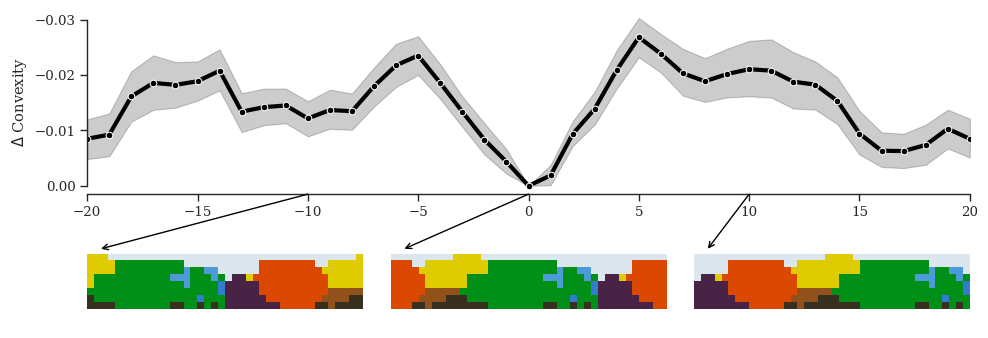

In [14]:
fig, axes = plt.subplots(nrows=2, 
                         figsize=(10, 3.5), 
                         gridspec_kw={'height_ratios': [2, 1]})

# First plot (Line plot)
sns.lineplot(
    data=df_horizontal, 
    x="shift", 
    y="convexity_diff", 
    linewidth=3,
    color='black',
    marker='o',
    ax=axes[0],
    errorbar=('ci', 95),
)
axes[0].set_xlabel("")
axes[0].set_ylabel(r"$\Delta$ Convexity")
axes[0].set_xlim(-20, 20)
axes[0].invert_yaxis()
sns.despine(ax=axes[0],
            # offset=1,
            trim=True,
            )

# Second row: 3 horizontally arranged images
img = plot_color_grid(lg_color[4][1:-1, 1:], rgb_dict, prior_m_matrix)

# Clean up the parent axis of the bottom row
axes[1].axis('off')  # Turn off the parent axis entirely
axes[1].grid(False)  # Ensure no grid persists

# Create subplots inside axes[1]
subgrid = axes[1].get_subplotspec().subgridspec(1, 3)
for idx, shift in enumerate([-10, 0, 10]):
    ax_img = fig.add_subplot(subgrid[0, idx])
    ax_img.imshow(np.roll(img, shift=shift, axis=1), interpolation='none')
    # ax_img.set_title(f'{shift}', fontsize=10, loc='left')
    ax_img.axis('off')  # Remove all borders and ticks
    ax_img.grid(False)  # Explicitly disable grid

    # rasterize the image to avoid aliasing artifacts
    ax_img.set_rasterization_zorder(1)

    # Add connecting lines
    con = ConnectionPatch(
        xyA=(shift, 0.0015),  # Point in the top plot (x=shift, y=0)
        xyB=(0.05, 1.1),    # Point in the bottom plot (center top of the image)
        coordsA="data",  # Use data coordinates for the top plot
        coordsB="axes fraction",  # Use axes fraction for the bottom plot
        axesA=axes[0],   # Top plot
        axesB=ax_img,    # Bottom subplot
        color="black",   # Line color # Dashed line
        linewidth=1, 
        arrowstyle='->'
    )
    fig.add_artist(con)

# Tighten layout
plt.tight_layout()
plt.subplots_adjust(wspace=0.1)  # Minimize space between images
plt.subplots_adjust(hspace=0.3)  # Minimize space between subplots
plt.savefig('../figures/Figure_6.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [10]:
lang_info[4]

'Aguacateco'